# ***In this assignment, students will build a CNN-based multi-class image classification model to classify images of 5 different animal species. Students will preprocess the dataset, train the CNN model, evaluate accuracy, and perform predictions on test images.***


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/animal-image-classification-5-species")

print("Path to dataset files:", path)

100%|██████████| 5.33M/5.33M [00:00<00:00, 114MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/miadul/animal-image-classification-5-species/versions/1


In [ ]:
import os
os.listdir(path)

['animals_dataset']

In [ ]:
animal_path=os.path.join(path,'animals_dataset')
print(animal_path)

/root/.cache/kagglehub/datasets/miadul/animal-image-classification-5-species/versions/1/animals_dataset


In [ ]:
os.listdir(animal_path)

['validation', 'test', 'train']

In [ ]:
test_path=os.path.join(animal_path,'test')
train_path=os.path.join(animal_path,'train')
validation_path=os.path.join(animal_path,'validation')

In [ ]:
os.listdir(test_path)

['lion', 'cat', 'dog', 'cow', 'deep']

In [ ]:
os.listdir(train_path)

['lion', 'cat', 'dog', 'cow', 'deep']

In [ ]:
os.listdir(validation_path)

['lion', 'cat', 'dog', 'cow', 'deep']

In [ ]:
lion_image=os.path.join(train_path,"lion")

In [ ]:
lion_path_image=os.path.join(lion_image,os.listdir(lion_image)[10])

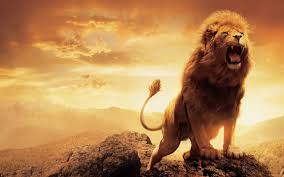

In [ ]:
import PIL.Image as im
im.open(lion_path_image)

In [ ]:
import tensorflow as tf
import tensorflow.keras
train_data=tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(128,128),
    batch_size=32,
    shuffle=True
)


Found 464 files belonging to 5 classes.


In [ ]:
import tensorflow as tf
import tensorflow.keras
test_data=tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)


Found 82 files belonging to 5 classes.


In [ ]:
import tensorflow as tf
import tensorflow.keras
valid_data=tf.keras.utils.image_dataset_from_directory(
    validation_path,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)


Found 83 files belonging to 5 classes.


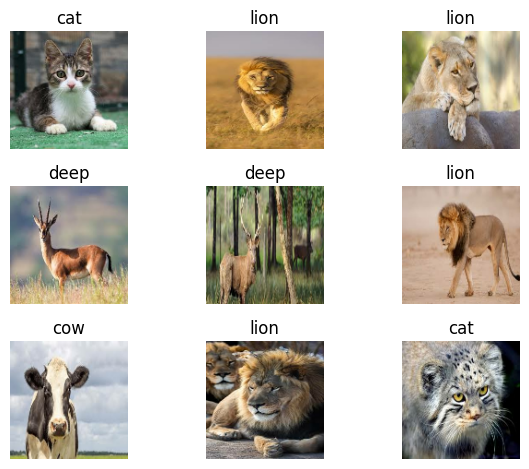

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Pehla batch lene ke liye .take(1) use karein
for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        # Tensor ko NumPy array aur uint8 me cast karein
        plt.imshow(images[i].numpy().astype(np.uint8))
        plt.title(train_data.class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow import keras
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal",input_shape=(128, 128, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Pre-trained Base Model (Imagenet Weights)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Pre-trained features freeze karein

# 2. Complete Model
model = keras.Sequential([
    # MobileNet expects inputs in [-1, 1] range
    layers.Rescaling(1./127.5, offset=-1, input_shape=(128, 128, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

In [ ]:
len(train_data),len(test_data),len(valid_data)

(15, 3, 3)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model ki summary dekhein
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks specify karein
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ModelCheckpoint(filepath='best_model.keras', monitor='val_accuracy', save_best_only=True)
]

In [ ]:

history= model.fit(
    train_data,epochs=40,
    validation_data=valid_data,
    callbacks=callbacks_list)

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.4526 - loss: 1.4309 - val_accuracy: 0.8313 - val_loss: 0.6021
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.7759 - loss: 0.6091 - val_accuracy: 0.9518 - val_loss: 0.2573
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.8685 - loss: 0.3881 - val_accuracy: 0.9759 - val_loss: 0.1616
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.8858 - loss: 0.3093 - val_accuracy: 0.9880 - val_loss: 0.1160
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9116 - loss: 0.2626 - val_accuracy: 0.9880 - val_loss: 0.0991
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9397 - loss: 0.2018 - val_accuracy: 0.9880 - val_loss: 0.0905
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9353 - loss: 0.1853 - val_accuracy: 0.9880 - val_loss: 0.0729
Epoch 8/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9397 - loss: 0.1721 - val_accuracy: 0.9880 - 

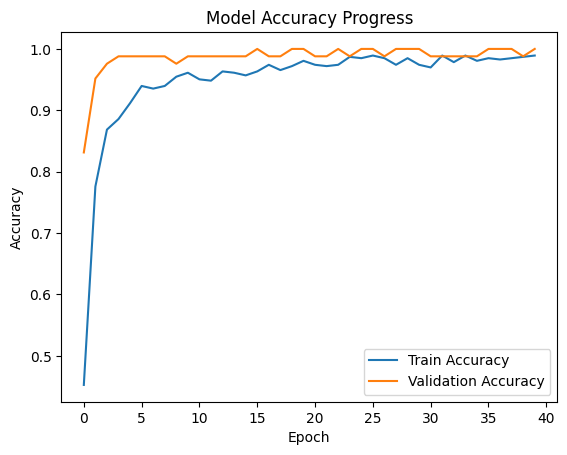

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Progress')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
model.evaluate(test_data)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9878 - loss: 0.0769


[0.07686865329742432, 0.9878048896789551]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


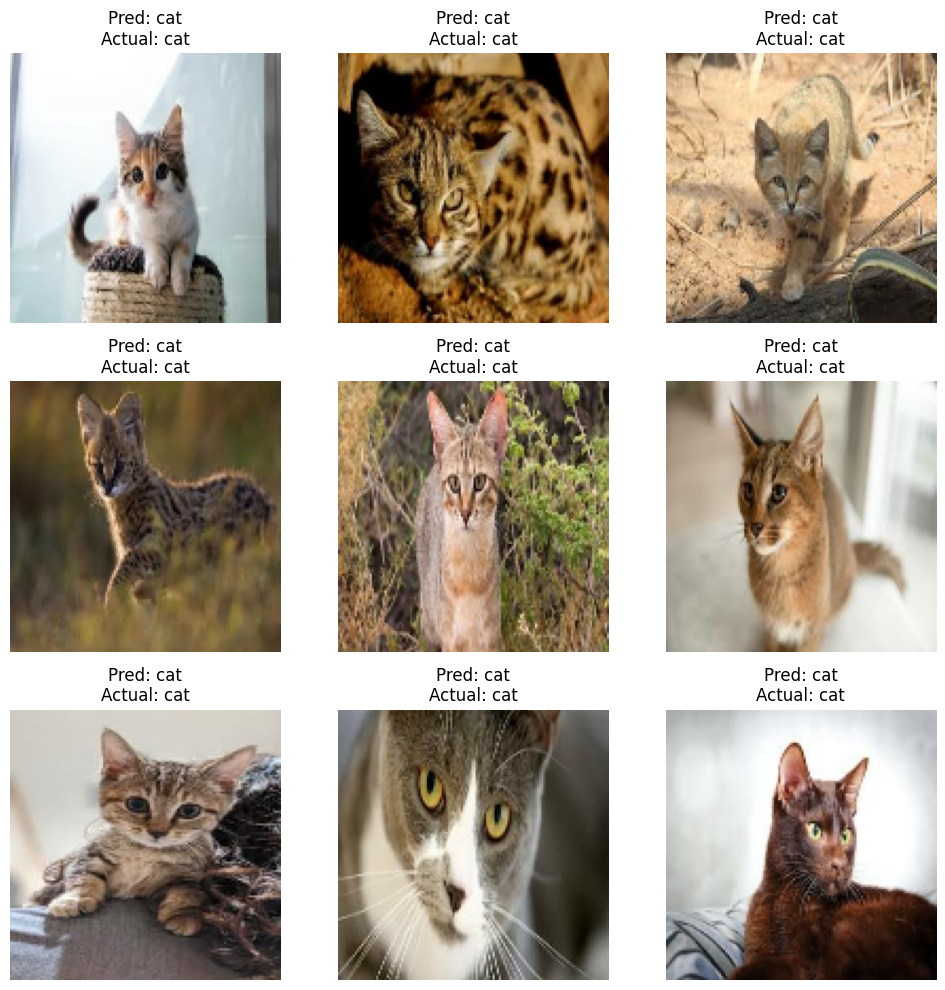

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Test dataset se 1 batch lein
for images, labels in test_data.take(1):
    # Model predictions generate karein
    predictions = model.predict(images)

    plt.figure(figsize=(10, 10))
    for i in range(9): # Pehli 9 images plot karein
        plt.subplot(3, 3, i + 1)

        # Original image show karein
        plt.imshow(images[i].numpy().astype("uint8"))

        # Predicted aur actual class find karein
        pred_class = train_data.class_names[np.argmax(predictions[i])]
        actual_class = train_data.class_names[labels[i]]

        plt.title(f"Pred: {pred_class}\nActual: {actual_class}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    break

In [ ]:
model.save("animal_classifier_model.keras")

In [71]:
import gradio as gr
import numpy as np
import tensorflow as tf

# 1. Saved model load karein
model = tf.keras.models.load_model("animal_classifier_model.keras")
class_names = train_data.class_names  # Class names list

# 2. Prediction function (Backend logic)
def predict_animal(image):
    # Image resize and preprocessing
    img = tf.image.resize(image, (128, 128))
    img_array = tf.expand_dims(img, 0)

    # Model prediction
    predictions = model.predict(img_array)[0]

    # Gradio Label format return karein (Dictionary of probabilities)
    return {class_names[i]: float(predictions[i]) for i in range(len(class_names))}

# 3. Simple Gradio UI (Pure Python)
interface = gr.Interface(
    fn=predict_animal,
    inputs=gr.Image(type="numpy", label="Upload Animal Image"),
    outputs=gr.Label(num_top_classes=3, label="Predictions"),
    title="🐾 Animal Classifier (MobileNetV2)",
    description="Image upload karein aur model instantly class predict kar dega!"
)

# 4. Launch UI (share=True se public link bhi mil jayega)
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://867d0baac6814dfdec.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
